<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/CO-3%20AT-1%20Module-1%20Exercise%3A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload a color image:


Saving ChatGPT Image Aug 12, 2026, 09_15_10 AM.png to ChatGPT Image Aug 12, 2026, 09_15_10 AM (1).png
Image loaded successfully!
Image size: (1024, 1536, 3)


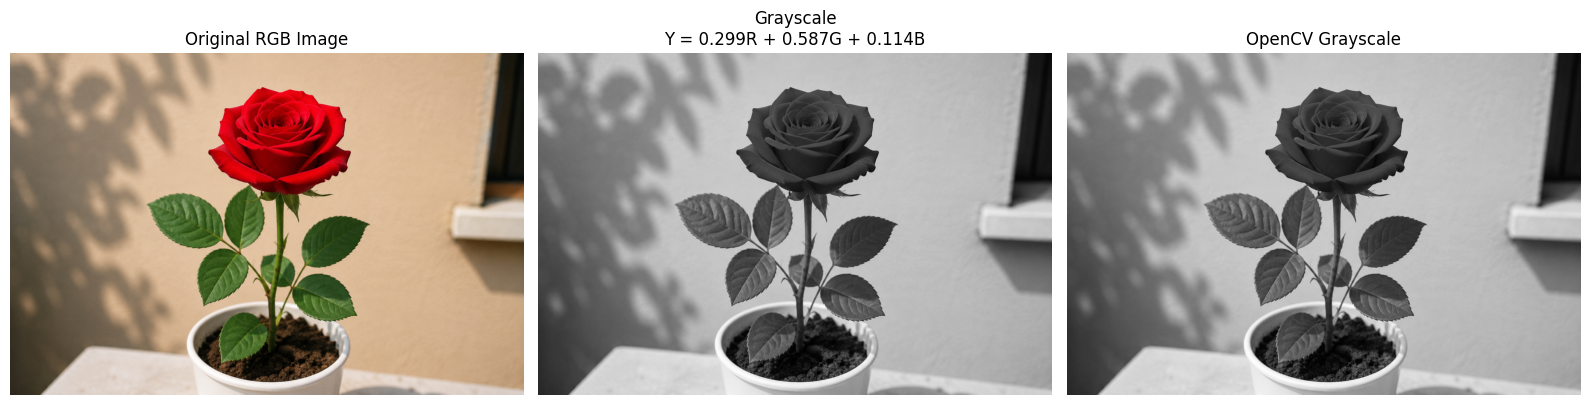

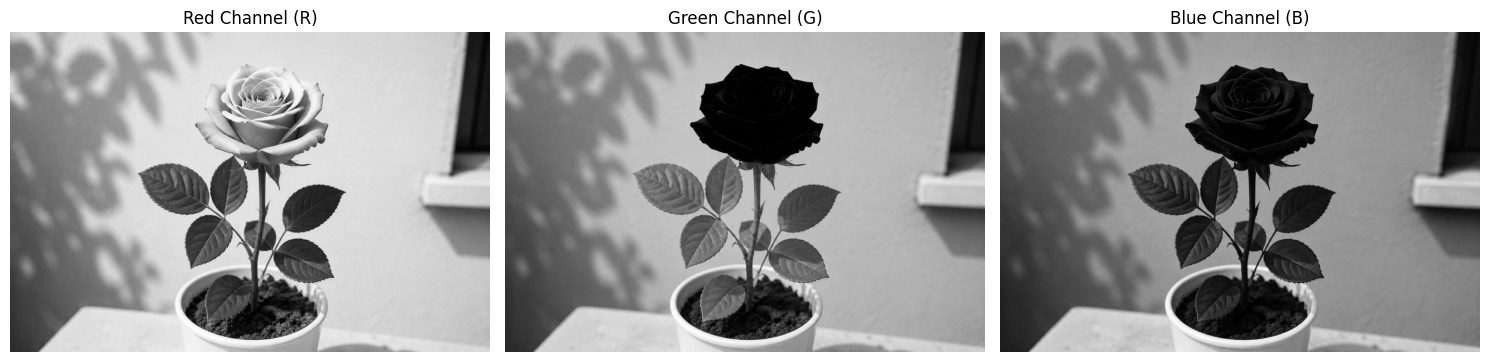

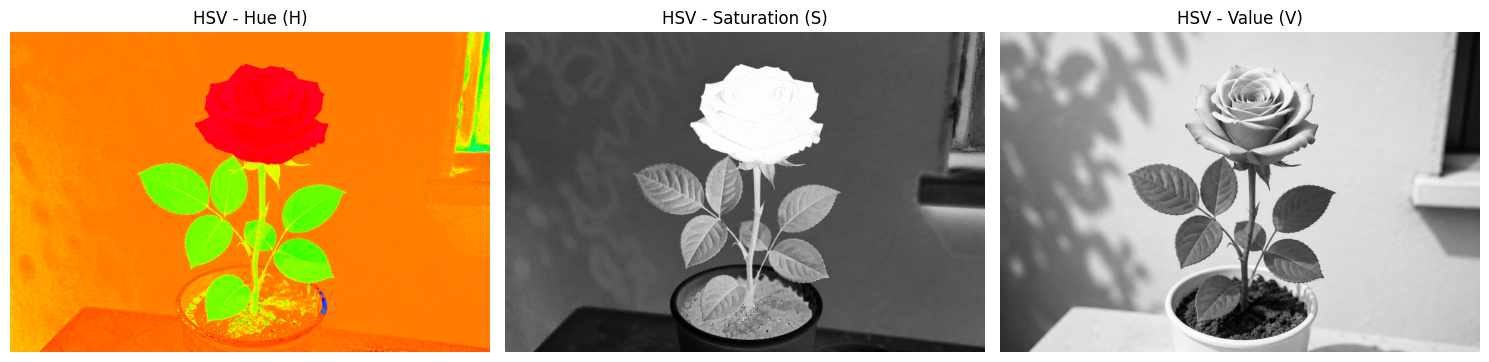

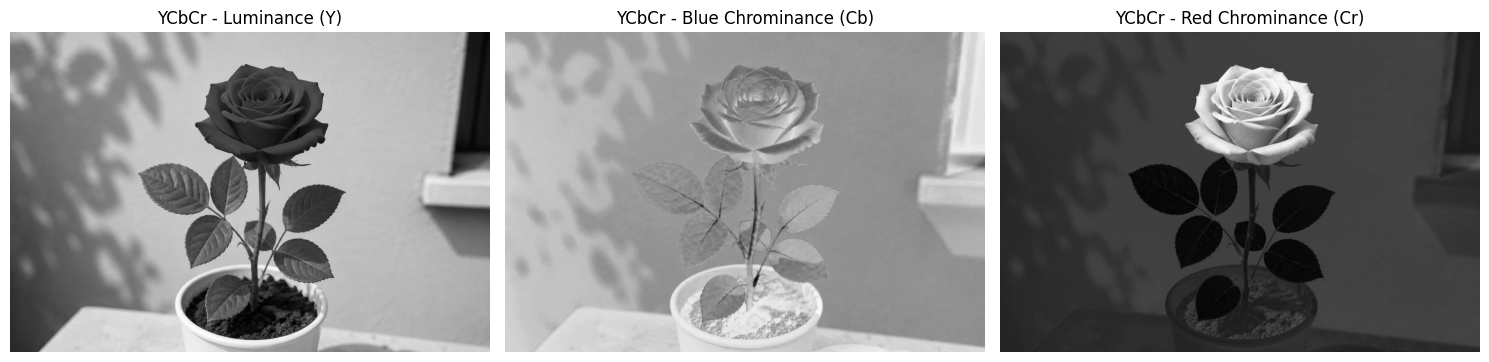

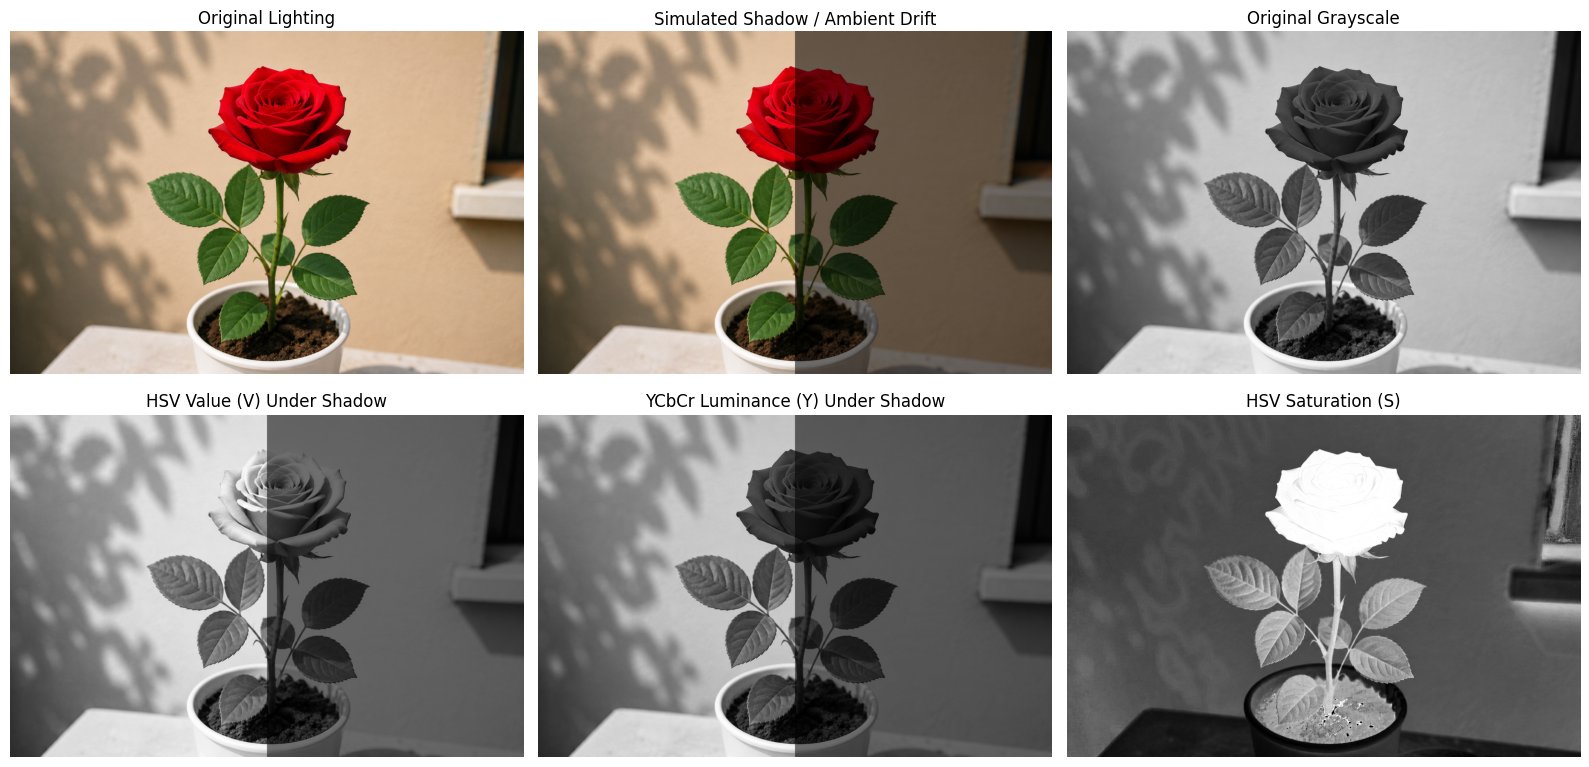


PIXEL VALUE COMPARISON

Original RGB pixel:
R = 221
G = 190
B = 158

Grayscale value:
195

HSV:
H = 15
S = 73
V = 221

YCbCr:
Y  = 196
Cr = 146
Cb = 107

EXERCISE 2 - OBSERVATION AND ANALYSIS

1. RGB REPRESENTATION:
   RGB stores color information in three separate channels:
   Red, Green and Blue.

   Changes in illumination can modify all three RGB values,
   making object tracking less stable under changing lighting.

2. GRAYSCALE CONVERSION:
   The standard luminance equation is:

       Y = 0.299R + 0.587G + 0.114B

   The weights are different because the human visual system
   has different sensitivity to red, green and blue.

   Green contributes the most, followed by red and blue.

3. HSV COLOR SPACE:
   HSV separates:
       H = Hue
       S = Saturation
       V = Value / brightness

   Hue represents the dominant color, while Value represents
   brightness.

4. YCbCr COLOR SPACE:
   Y represents luminance/brightness.

   Cb and Cr represent chrominance/color information.



In [5]:
# ============================================================
# MODULE 1 - EXERCISE 2
# COLOR SPACE ROBUSTNESS UNDER AMBIENT DRIFT
# RGB vs Grayscale vs HSV vs YCbCr
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# STEP 1: UPLOAD IMAGE
# ============================================================

print("Upload a color image:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img_bgr = cv2.imread(filename)

if img_bgr is None:
    print("ERROR: Image could not be loaded.")

else:

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print("Image loaded successfully!")
    print("Image size:", img_rgb.shape)

    # ========================================================
    # STEP 2: RGB CHANNELS
    # ========================================================

    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    # ========================================================
    # STEP 3: GRAYSCALE USING WEIGHTED FORMULA
    #
    # Y = 0.299R + 0.587G + 0.114B
    # ========================================================

    gray_manual = (
        0.299 * R +
        0.587 * G +
        0.114 * B
    ).astype(np.uint8)

    # OpenCV grayscale for comparison
    gray_cv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2GRAY
    )

    # ========================================================
    # STEP 4: CONVERT RGB IMAGE TO HSV
    # ========================================================

    hsv = cv2.cvtColor(
        img_rgb,
        cv2.COLOR_RGB2HSV
    )

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # ========================================================
    # STEP 5: CONVERT RGB IMAGE TO YCbCr
    # ========================================================

    ycbcr = cv2.cvtColor(
        img_rgb,
        cv2.COLOR_RGB2YCrCb
    )

    Y = ycbcr[:, :, 0]
    Cr = ycbcr[:, :, 1]
    Cb = ycbcr[:, :, 2]

    # ========================================================
    # STEP 6: DISPLAY ORIGINAL + GRAYSCALE
    # ========================================================

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original RGB Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray_manual, cmap="gray")
    plt.title("Grayscale\nY = 0.299R + 0.587G + 0.114B")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gray_cv, cmap="gray")
    plt.title("OpenCV Grayscale")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 7: DISPLAY RGB CHANNELS
    # ========================================================

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(R, cmap="gray")
    plt.title("Red Channel (R)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(G, cmap="gray")
    plt.title("Green Channel (G)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(B, cmap="gray")
    plt.title("Blue Channel (B)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 8: DISPLAY HSV CHANNELS
    # ========================================================

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(H, cmap="hsv")
    plt.title("HSV - Hue (H)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(S, cmap="gray")
    plt.title("HSV - Saturation (S)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(V, cmap="gray")
    plt.title("HSV - Value (V)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 9: DISPLAY YCbCr CHANNELS
    # ========================================================

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(Y, cmap="gray")
    plt.title("YCbCr - Luminance (Y)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(Cb, cmap="gray")
    plt.title("YCbCr - Blue Chrominance (Cb)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(Cr, cmap="gray")
    plt.title("YCbCr - Red Chrominance (Cr)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 10: SIMULATE AMBIENT LIGHTING / SHADOW
    # ========================================================

    # Create artificial shadow by reducing brightness
    shadow_img = img_rgb.astype(np.float32)

    # Darken the right half of image
    width = shadow_img.shape[1]

    shadow_img[:, width // 2:, :] *= 0.45

    shadow_img = np.clip(
        shadow_img,
        0,
        255
    ).astype(np.uint8)

    # ========================================================
    # STEP 11: CONVERT SHADOW IMAGE TO HSV
    # ========================================================

    shadow_hsv = cv2.cvtColor(
        shadow_img,
        cv2.COLOR_RGB2HSV
    )

    shadow_H = shadow_hsv[:, :, 0]
    shadow_S = shadow_hsv[:, :, 1]
    shadow_V = shadow_hsv[:, :, 2]

    # ========================================================
    # STEP 12: CONVERT SHADOW IMAGE TO YCbCr
    # ========================================================

    shadow_ycbcr = cv2.cvtColor(
        shadow_img,
        cv2.COLOR_RGB2YCrCb
    )

    shadow_Y = shadow_ycbcr[:, :, 0]
    shadow_Cr = shadow_ycbcr[:, :, 1]
    shadow_Cb = shadow_ycbcr[:, :, 2]

    # ========================================================
    # STEP 13: DISPLAY AMBIENT LIGHTING CHANGE
    # ========================================================

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Lighting")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(shadow_img)
    plt.title("Simulated Shadow / Ambient Drift")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(gray_manual, cmap="gray")
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(shadow_V, cmap="gray")
    plt.title("HSV Value (V) Under Shadow")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(shadow_Y, cmap="gray")
    plt.title("YCbCr Luminance (Y) Under Shadow")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(shadow_S, cmap="gray")
    plt.title("HSV Saturation (S)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 14: SAMPLE PIXEL COMPARISON
    # ========================================================

    y_pos = img_rgb.shape[0] // 2
    x_pos = img_rgb.shape[1] // 4

    print("\n" + "=" * 65)
    print("PIXEL VALUE COMPARISON")
    print("=" * 65)

    print("\nOriginal RGB pixel:")
    print("R =", R[y_pos, x_pos])
    print("G =", G[y_pos, x_pos])
    print("B =", B[y_pos, x_pos])

    print("\nGrayscale value:")
    print(gray_manual[y_pos, x_pos])

    print("\nHSV:")
    print("H =", H[y_pos, x_pos])
    print("S =", S[y_pos, x_pos])
    print("V =", V[y_pos, x_pos])

    print("\nYCbCr:")
    print("Y  =", Y[y_pos, x_pos])
    print("Cr =", Cr[y_pos, x_pos])
    print("Cb =", Cb[y_pos, x_pos])

    # ========================================================
    # STEP 15: FINAL SUMMARY
    # ========================================================

    print("\n" + "=" * 70)
    print("EXERCISE 2 - OBSERVATION AND ANALYSIS")
    print("=" * 70)

    print("""
1. RGB REPRESENTATION:
   RGB stores color information in three separate channels:
   Red, Green and Blue.

   Changes in illumination can modify all three RGB values,
   making object tracking less stable under changing lighting.

2. GRAYSCALE CONVERSION:
   The standard luminance equation is:

       Y = 0.299R + 0.587G + 0.114B

   The weights are different because the human visual system
   has different sensitivity to red, green and blue.

   Green contributes the most, followed by red and blue.

3. HSV COLOR SPACE:
   HSV separates:
       H = Hue
       S = Saturation
       V = Value / brightness

   Hue represents the dominant color, while Value represents
   brightness.

4. YCbCr COLOR SPACE:
   Y represents luminance/brightness.

   Cb and Cr represent chrominance/color information.

   This separation makes YCbCr useful for image processing
   where brightness and color information need to be handled
   separately.

5. AMBIENT LIGHTING:
   When a shadow is introduced, brightness-related components
   such as V and Y change strongly.

   Chrominance components can be used separately from brightness
   when designing a more robust tracking pipeline.

6. PREPROCESSING WORKFLOW:

       RGB Image
           |
           v
       Color Space Conversion
           |
        +--+---------+
        |            |
        v            v
      HSV          YCbCr
        |            |
        v            v
     H / S / V     Y / Cb / Cr
        |            |
        +-----+------+
              |
              v
       Object Detection /
       Tracking

7. CONCLUSION:
   RGB directly mixes color and illumination information.
   HSV and YCbCr separate brightness-related information from
   color information, making them useful for improving robustness
   under changing ambient lighting.
    """)

    print("=" * 70)
    print("EXERCISE 2 COMPLETED SUCCESSFULLY!")
    print("=" * 70)